<a href="https://colab.research.google.com/github/DeepthiGovindapuram/PredictiveAnalysis/blob/SAP/SAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Size_sqft  Bedrooms  Age          Price
0       1846         1   14  161768.572022
1       1879         3    4  153052.893469
2       1324         4   22   90072.831209
3        770         3   12   65443.953184
4       3301         1    5  233747.979510
Mean Squared Error: 2613709406.5011606
R^2 Score: 0.6231837127606351
Intercept: 20115.58990535217
Coefficients: [('Size_sqft', np.float64(46.70815917770561)), ('Bedrooms', np.float64(12822.287828850767)), ('Age', np.float64(-275.5075860095167))]


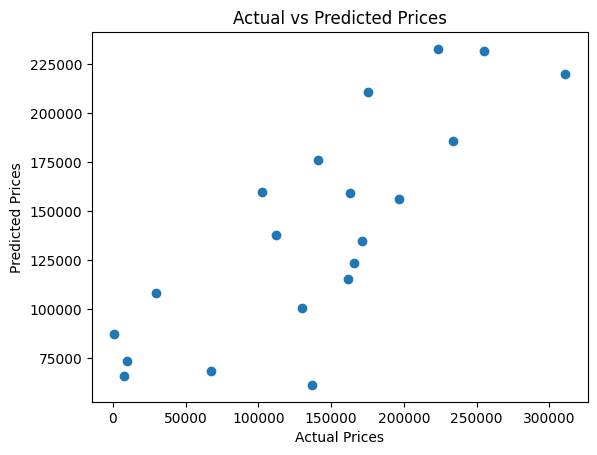

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


data = pd.DataFrame({
    "Size_sqft": np.random.randint(500, 4000, 100),
    "Bedrooms": np.random.randint(1, 5, 100),
    "Age": np.random.randint(0, 30, 100)
})

data["Price"] = (
    50 * data["Size_sqft"]
    + 20000 * data["Bedrooms"]
    - 1000 * data["Age"]
    + np.random.normal(0, 50000, 100)
)

print(data.head())


X = data[["Size_sqft", "Bedrooms", "Age"]]
y = data["Price"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))


print("Intercept:", model.intercept_)
print("Coefficients:", list(zip(X.columns, model.coef_)))


plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'Admission_Predict.csv'


Sample Data:
   GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research  \
0        292          114                  1  3.8  2.3  7.35         1   
1        316           95                  1  4.4  1.9  9.05         1   
2        319          102                  1  2.3  3.4  8.25         0   
3        296          104                  4  3.6  4.6  6.64         0   
4        334          103                  4  2.8  2.9  9.45         1   

   Chance of Admit  
0              1.0  
1              1.0  
2              1.0  
3              1.0  
4              1.0  

Model Evaluation:
Mean Squared Error: 0.0
R^2 Score: 1.0

Model Coefficients:
Intercept: 1.0
  GRE Score: 0.0000
  TOEFL Score: 0.0000
  University Rating: 0.0000
  SOP: 0.0000
  LOR: 0.0000
  CGPA: 0.0000
  Research: 0.0000


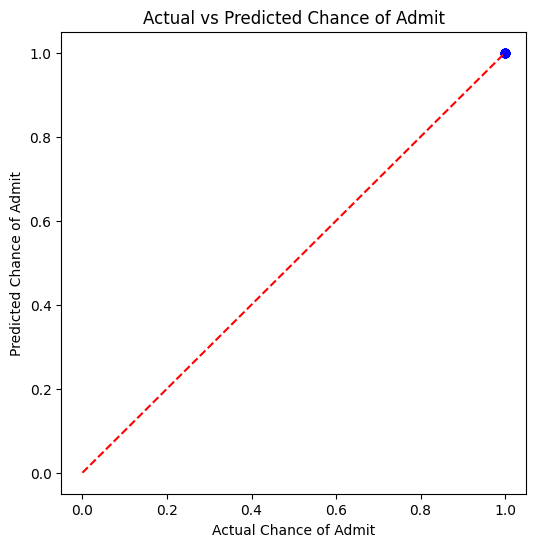

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


data = pd.DataFrame({
    "GRE Score": np.random.randint(290, 340, 100),
    "TOEFL Score": np.random.randint(90, 120, 100),
    "University Rating": np.random.randint(1, 5, 100),
    "SOP": np.round(np.random.uniform(1, 5, 100), 1),
    "LOR": np.round(np.random.uniform(1, 5, 100), 1),
    "CGPA": np.round(np.random.uniform(6.0, 10.0, 100), 2),
    "Research": np.random.randint(0, 2, 100)
})


data["Chance of Admit"] = (
    0.003 * data["GRE Score"]
    + 0.0025 * data["TOEFL Score"]
    + 0.02 * data["University Rating"]
    + 0.03 * data["SOP"]
    + 0.03 * data["LOR"]
    + 0.08 * data["CGPA"]
    + 0.1 * data["Research"]
    + np.random.normal(0, 0.02, 100)
)

data["Chance of Admit"] = data["Chance of Admit"].clip(0, 1)

print("\nSample Data:")
print(data.head())


X = data.drop(columns=["Chance of Admit"])
y = data["Chance of Admit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)



print("\nModel Evaluation:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

print("\nModel Coefficients:")
print("Intercept:", model.intercept_)
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat}: {coef:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.title('Actual vs Predicted Chance of Admit')
plt.show()
